<a href="https://colab.research.google.com/github/jrdndj/ImproVisAR-PilotPlots/blob/main/Study3_cog_load_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-2-74a7c519caa0>:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pair', y='Statistic', data=pairwise_df, palette='Blues', ci=None)
<ipython-input-2-74a7c519caa0>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pair', y='Statistic', data=pairwise_df, palette='Blues', ci=None)


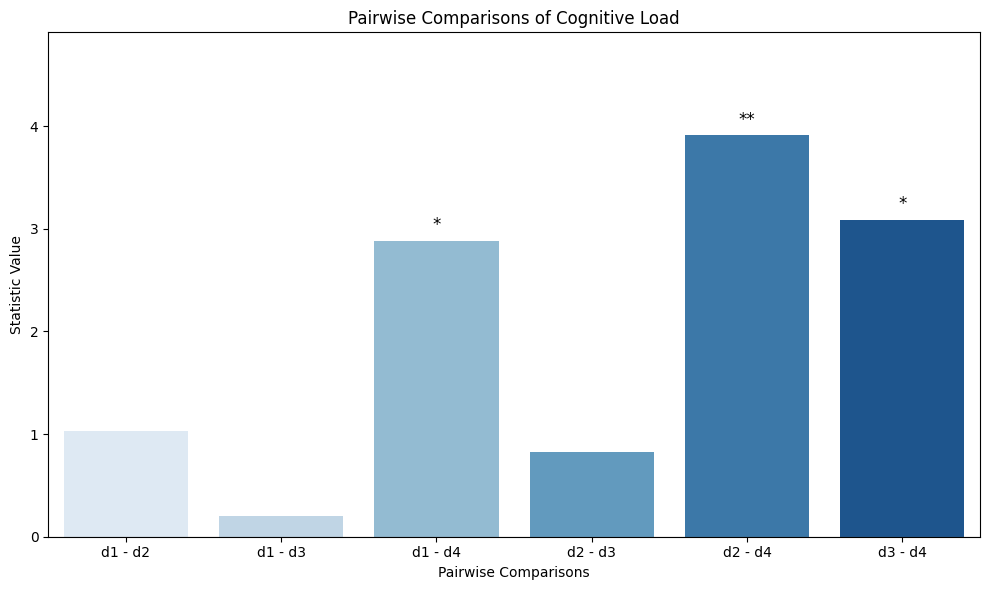

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data creation
pairwise_data = {
    "Pair": ["d1 - d2", "d1 - d3", "d1 - d4", "d2 - d3", "d2 - d4", "d3 - d4"],
    "Statistic": [1.030, 0.206, 2.885, 0.824, 3.915, 3.091],
    "p_value": [0.330, 0.841, 0.018, 0.431, 0.004, 0.013]
}

# Create a DataFrame
pairwise_df = pd.DataFrame(pairwise_data)

# Add significance stars based on p-value thresholds
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

pairwise_df['Significance'] = pairwise_df['p_value'].apply(significance_stars)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Pair', y='Statistic', data=pairwise_df, palette='Blues', ci=None)

# Add significance stars to the plot
for index, row in pairwise_df.iterrows():
    plt.text(index, row.Statistic + 0.1, row.Significance, ha='center', fontsize=12)

# Labels and title
plt.xlabel('Pairwise Comparisons')
plt.ylabel('Statistic Value')
plt.title('Pairwise Comparisons of Cognitive Load')
plt.axhline(0, color='gray', lw=0.8)
plt.ylim(0, pairwise_df['Statistic'].max() + 1)

# Show plot
plt.tight_layout()
plt.show()


In [6]:
import numpy as np
from scipy.stats import ttest_ind

# Data
group1 = [1123, 1356, 1090, 1172, 3502, 1119]
group2 = [1169, 1103, 982, 1156, 1108, 1069]

# Perform independent t-test
t_stat, p_value = ttest_ind(group1, group2)

print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print("Significant difference between groups (Reject H0).")
else:
    print("No significant difference between groups (Fail to reject H0).")


T-statistic: 1.1821, P-value: 0.2645
No significant difference between groups (Fail to reject H0).


test compose on the fly variations


<ipython-input-4-f66e31fcca49>:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([group1, group2], labels=["Group 1", "Group 2"])


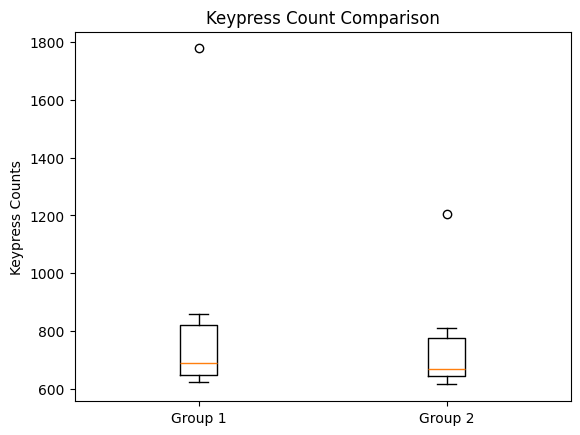

In [4]:
import matplotlib.pyplot as plt

plt.boxplot([group1, group2], labels=["Group 1", "Group 2"])
plt.title("Keypress Count Comparison")
plt.ylabel("Keypress Counts")
plt.show()


now visualize it

now test compose on the fly question and answer


In [8]:
# Group 1 data
group1_qa = [668, 858, 643, 710, 1778, 622]

# Group 2 data
group2_qa = [673, 662, 1206, 615, 640, 810]

import numpy as np
from scipy.stats import ttest_ind

# Perform independent t-test
t_stat, p_value = ttest_ind(group1, group2)

print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("Significant difference between groups (Reject H0).")
else:
    print("No significant difference between groups (Fail to reject H0).")


T-statistic: 1.1821, P-value: 0.2645
No significant difference between groups (Fail to reject H0).


visualize it


<ipython-input-3-c93cb2191a41>:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([group1, group2], labels=["Group 1", "Group 2"])


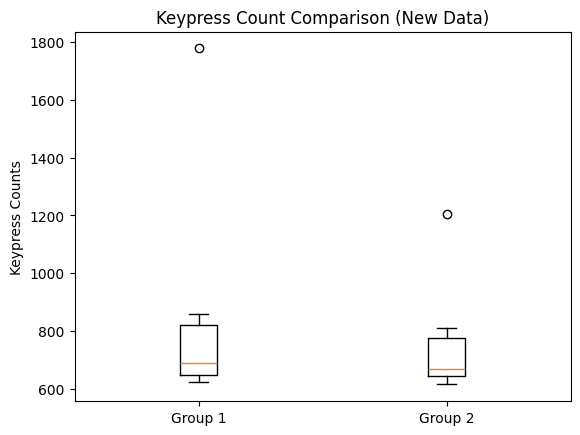

In [3]:
import matplotlib.pyplot as plt

plt.boxplot([group1_qa, group2_qa], labels=["Group 1", "Group 2"])
plt.title("Keypress Count Comparison (New Data)")
plt.ylabel("Keypress Counts")
plt.show()


since there is no significant difference which makes sense. lets look at compute growth over time from day 2 to day 4

That makes sense! Given the constraint of having the same number of bars per recording, here are alternative ways to analyze changes in engagement (keypress counts):

---

### **1. Compute Growth or Decline Rates**  
Rather than focusing solely on absolute numbers, calculate the percentage change in keypresses from Day 2 to Day 4 for each participant in each group:
  
\[
\text{Change Rate} = \frac{\text{Day 4 Keypress Count} - \text{Day 2 Keypress Count}}{\text{Day 2 Keypress Count}} \times 100
\]

This reveals whether participants became more or less engaged over time.  

#### Example Code:
```python
group1_deltas = [(d4 - d2) / d2 * 100 for d2, d4 in zip(group1[::2], group1[1::2])]
group2_deltas = [(d4 - d2) / d2 * 100 for d2, d4 in zip(group2[::2], group2[1::2])]

print("Group 1 Engagement Change Rates:", group1_deltas)
print("Group 2 Engagement Change Rates:", group2_deltas)
```

---

### **2. Analyze Engagement Variability**
Examine the variance or standard deviation in keypress counts. If one group shows less variability, it could indicate more consistent engagement levels.

---

### **3. Look for Distribution Overlap**
Plot histograms or kernel density plots to check if the distributions of keypress counts overlap between groups. Large overlap suggests similar engagement, while separation may indicate engagement differences.

#### Example Code:
```python
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(group1, label="Group 1", fill=True, alpha=0.3)
sns.kdeplot(group2, label="Group 2", fill=True, alpha=0.3)
plt.title("Keypress Distribution Between Groups")
plt.legend()
plt.show()
```

---

### **4. Examine Individual Changes (Paired Analysis)**  
Treat each participant as their own baseline and compare changes over time:
  
\[
\Delta \text{Engagement} = \text{Day 4 Keypress Count} - \text{Day 2 Keypress Count}
\]

You can use a paired t-test (`scipy.stats.ttest_rel`) to evaluate these within-participant changes for both groups.


Group 1 Engagement Change Rates: [20.7479964381122, 7.522935779816514, -68.04683038263849]
Group 2 Engagement Change Rates: [-5.645851154833191, 17.718940936863543, -3.5198555956678703]


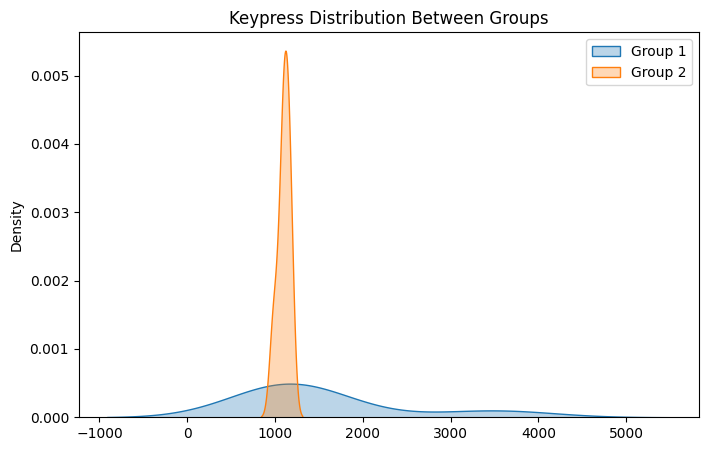

In [10]:
# Data
group1 = [1123, 1356, 1090, 1172, 3502, 1119]
group2 = [1169, 1103, 982, 1156, 1108, 1069]

group1_deltas = [(d4 - d2) / d2 * 100 for d2, d4 in zip(group1[::2], group1[1::2])]
group2_deltas = [(d4 - d2) / d2 * 100 for d2, d4 in zip(group2[::2], group2[1::2])]

print("Group 1 Engagement Change Rates:", group1_deltas)
print("Group 2 Engagement Change Rates:", group2_deltas)

import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(group1, label="Group 1", fill=True, alpha=0.3)
sns.kdeplot(group2, label="Group 2", fill=True, alpha=0.3)
plt.title("Keypress Distribution Between Groups")
plt.legend()
plt.show()


